In [1]:
import numpy as np 
import os 
import xarray as xr
import pandas as pd
#from scipy.io import savemat
from collections import OrderedDict
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import matplotlib as mpl
from matplotlib import colors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import ListedColormap

import mplcursors

In [2]:
max_display_options = ['display.max_seq_items', 'display.max_colwidth', 'display.max_dir_items', 'display.max_columns', 'display.max_rows']
for param in range(0,len(max_display_options)):
    pd.set_option(max_display_options[param], None)

In [3]:
#Get merged data from USOS
all_days_filepath = '../../CampaignData_and_Merges/R0/CSL_MobileLab_Parked/merged/rev_15min/all_CSL_MobileLab_Parked_rev15min_iWASupdated.nc'
all_days_filepath_load = xr.open_dataset(all_days_filepath)
df_alldays = all_days_filepath_load.to_dataframe()
df_alldays.set_index('time_local', inplace=True)

In [ ]:
#Identify list of relevant VOCs we want data availability for

misc_list = ['HCOOH_CIMS', 'HCHO_CRDS']

PTR_list = ['Methanol_PTR','Acetonitrile_PTR','Acetaldehyde_PTR','Ethanol_PTR','Methanethiol_PTR','Acrolein_PTR','Acetone_Propanal_PTR','DMS_PTR',
            'MVK_MACR_PTR','Benzene_PTR','Toluene_PTR','Styrene_PTR','Benzaldehyde_PTR','C8Aromatics_PTR','C9Aromatics_PTR','Naphthalene_PTR',
            'Octanal_PTR','Monoterpenes_PTR','Nonanal_PTR','C7H4ClF3_PTR','D5_siloxane_PTR']

WAS_list = ['Acetone_WAS','Acrolein_WAS','Benzene_WAS','C2Cl4_WAS','C2HCl3_WAS','CCl4_WAS','CF2Cl2_WAS','CFCl3_WAS','CH2Cl2_WAS','CH3Br_WAS',
            'CycloPentane_WAS','Ethyl_WAS','Ethane_WAS','Ethene_WAS','Ethyne_WAS','Furan_WAS','Isoprene_WAS','Limonene_WAS',
            'MethylCycloHexane_WAS','MethylCycloPentane_WAS','Propane_WAS','Propene_WAS','Toluene_WAS','Alpha_Pinene_WAS','Beta_Pinene_WAS',
            'c2Butene_WAS','c2Pentene_WAS','iButane_WAS','iPentane_WAS','iPropylBenzene_WAS','iPropylONO2_WAS','m_p_Xylene_WAS','nButane_WAS',
            'nDecane_WAS','nHeptane_WAS','nHexane_WAS','nNonane_WAS','nOctane_WAS','nPentane_WAS','nPropylBenzene_WAS','nPropylONO2_WAS',
            'o_Xylene_WAS','t2Butene_WAS','t2Pentene_WAS','x123_TriMethylBenzene_WAS','x124_TriMethylBenzene_WAS','x135_TriMethylBenzene_WAS',
            'x13_Butadiene_WAS','x1_Butene_WAS','x1_Pentene_WAS','x224_TriMethylPentane_WAS','x22_DiMethylButane_WAS','x2_EthylToluene_WAS',
            'x2_MethylPentane_WAS','x3_MethylPentane_WAS','x3_x4_EthylToluene_WAS']

VOC_list = [misc_list, PTR_list, WAS_list]

In [42]:
df_usos_vocs=pd.DataFrame(index=df_alldays.index)

for instr in VOC_list:
    for col in range(0, len(instr)):
        # Everything that was a NaN or negative is assigned a 0, positive values are assigned a 1
        df_usos_vocs[instr[col]] = np.where((df_alldays[instr[col]] > 0) & (~df_alldays[instr[col]].isna()), 1, 0)
df_usos_vocs_transposed=df_usos_vocs.T

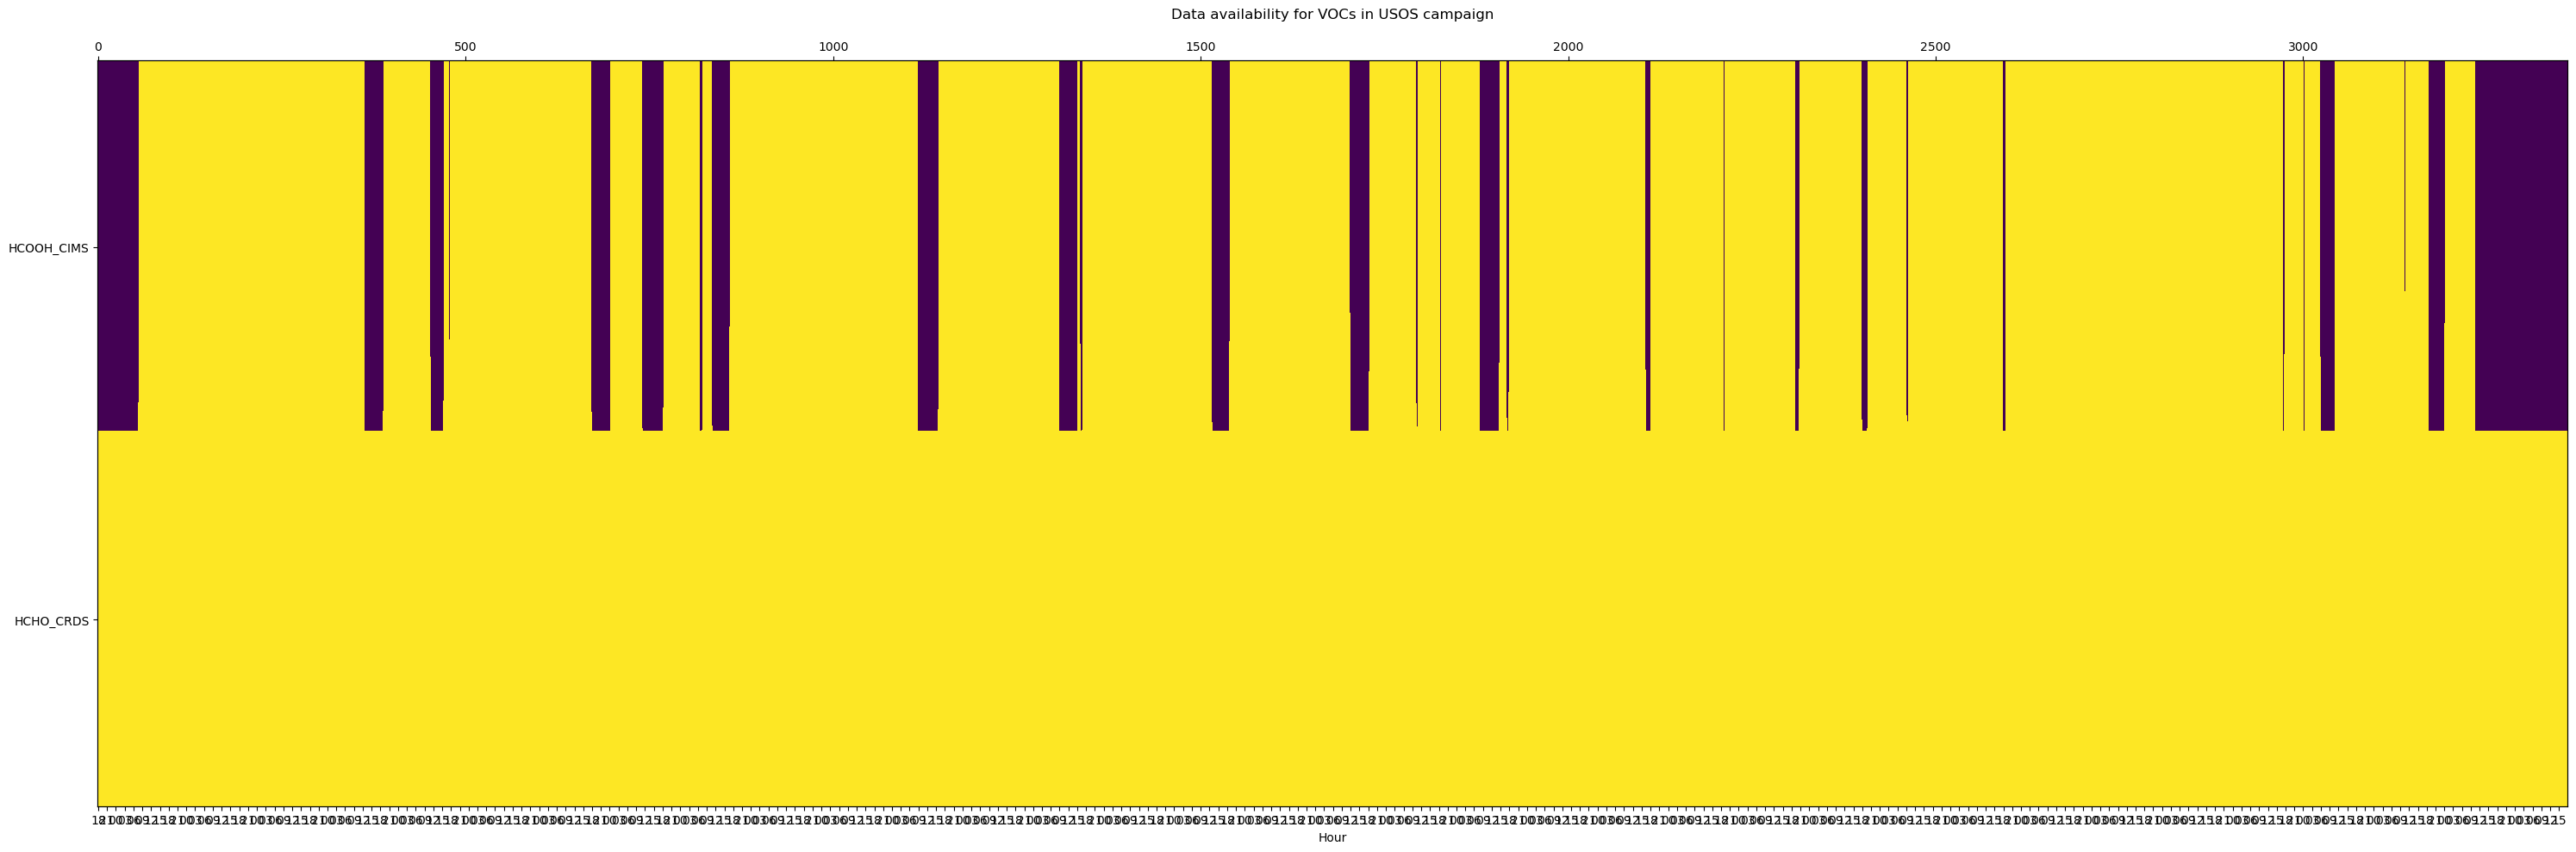

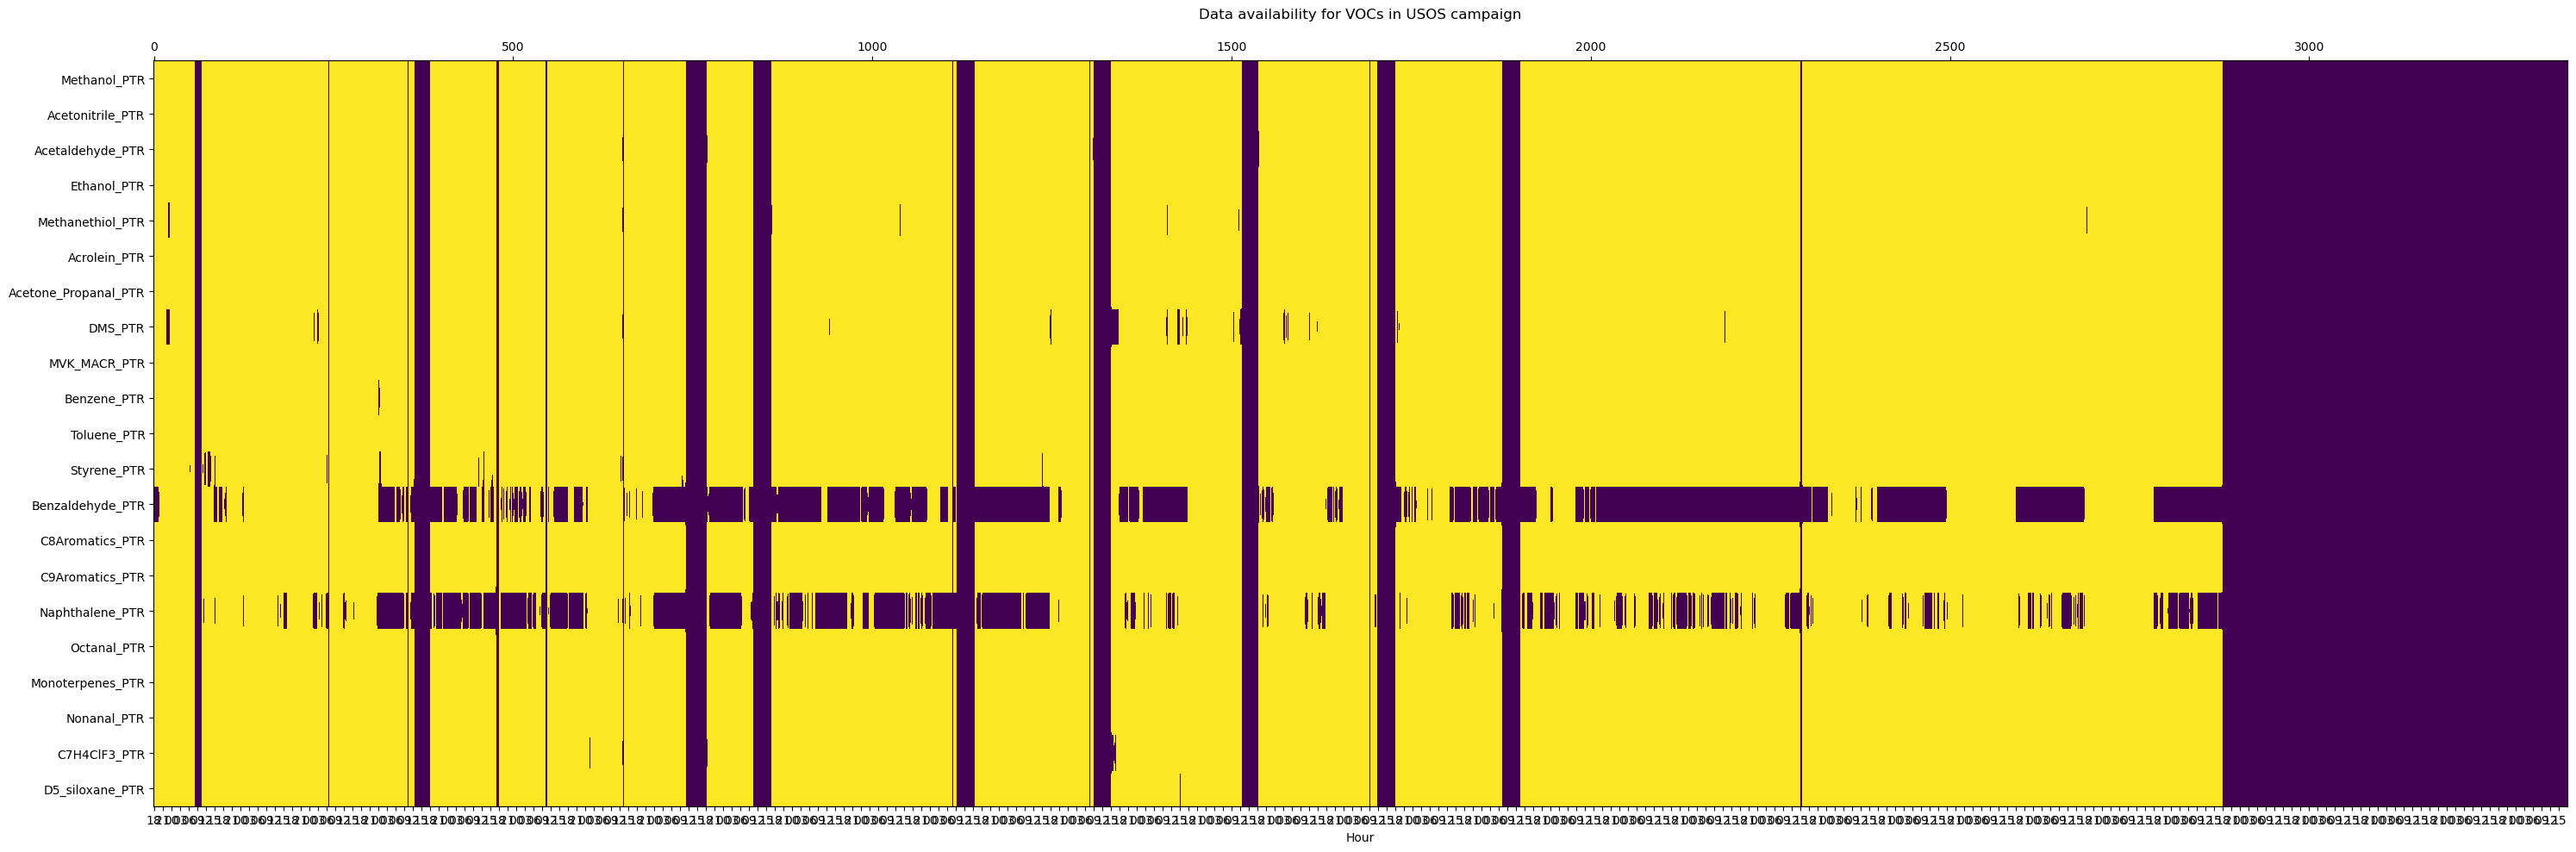

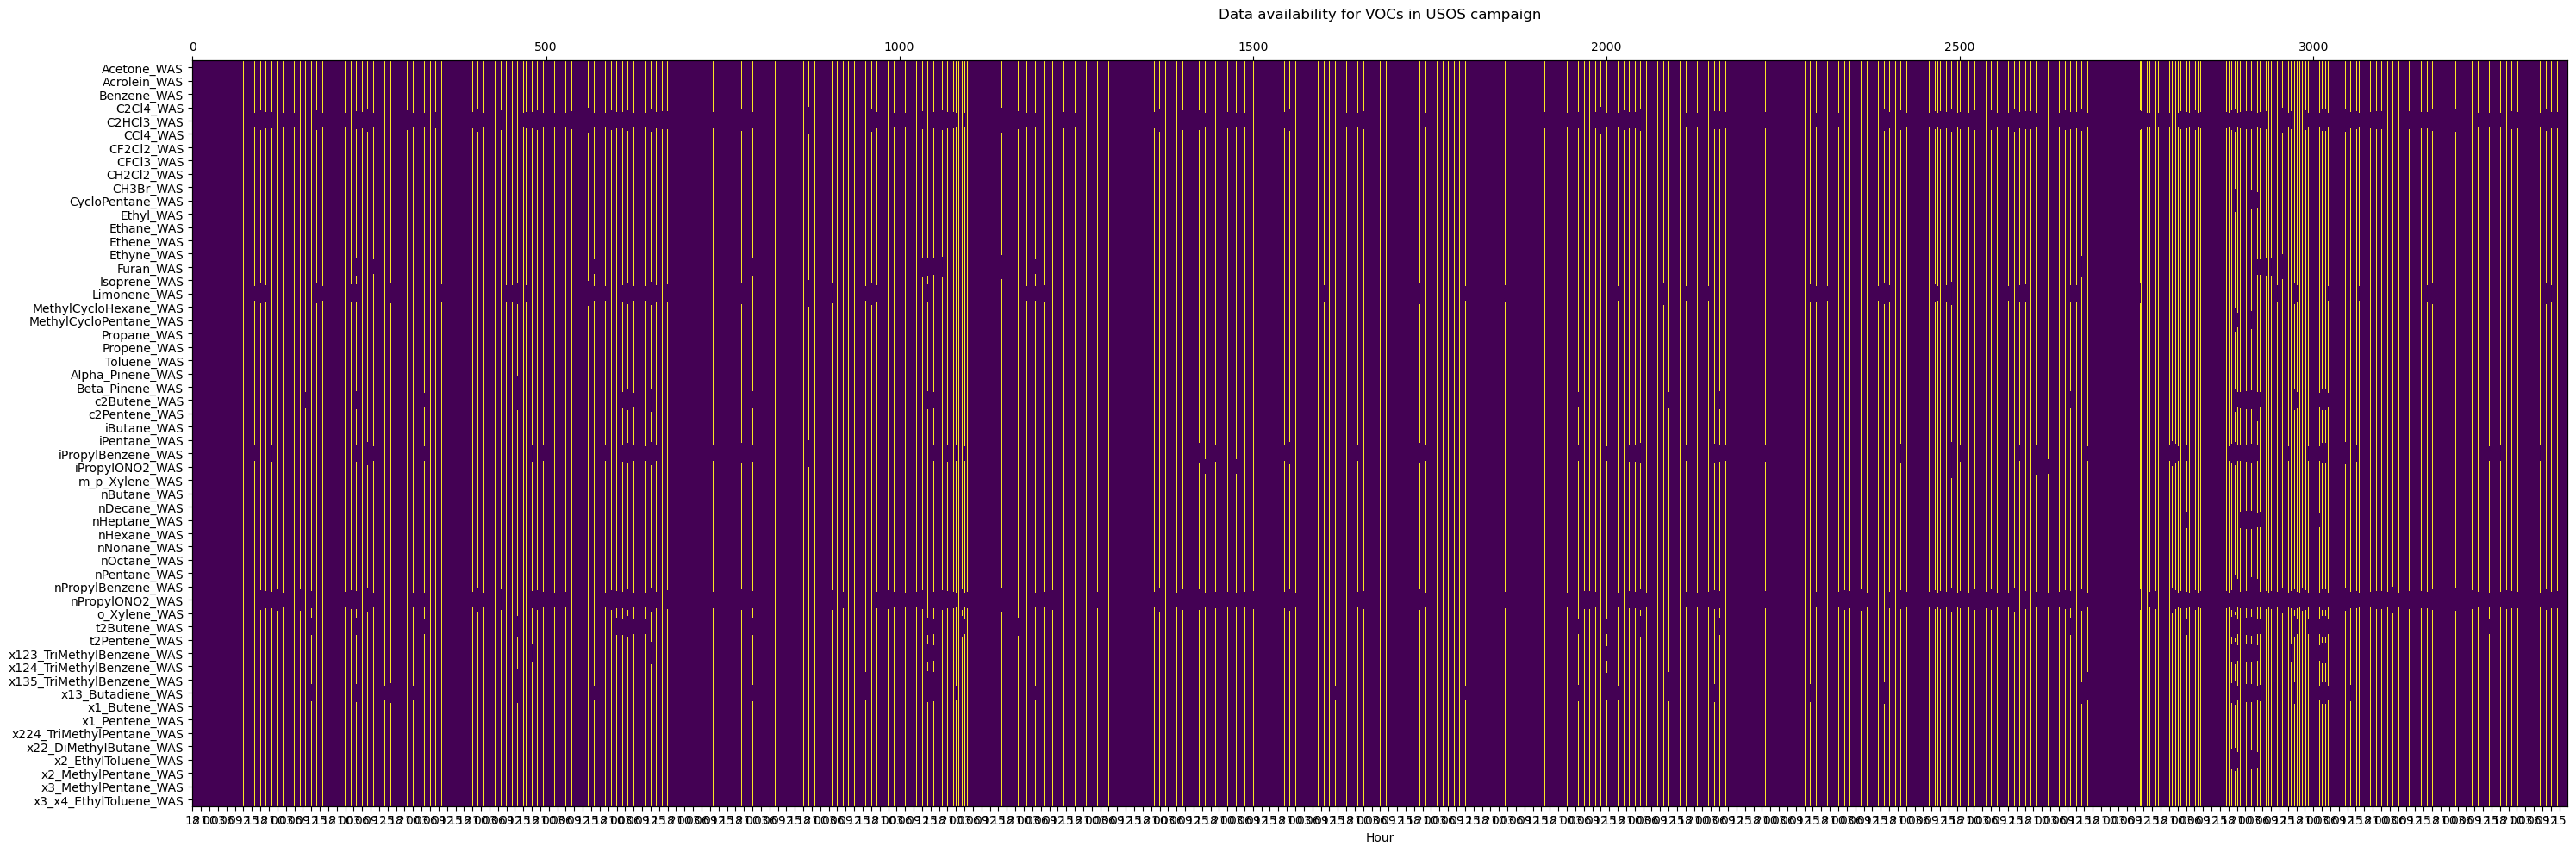

In [45]:

#alter viridis colormap to only have 2 color options
viridis = plt.cm.viridis
colors = [viridis(0.0), viridis(1.0)]
two_color_viridis = ListedColormap(colors)

# Create the heatmap using imshow
fig, ax = plt.subplots(figsize=(30, 10))
ax.imshow(df_usos_vocs_transposed[0:2], aspect='auto', cmap=two_color_viridis)
# Set x-ticks and y-ticks
ax.set_xticks(ticks=range(0,len(df_usos_vocs_transposed.columns),12), labels=df_usos_vocs_transposed.columns.strftime('%H')[0::12])
ax.set_yticks(ticks=np.arange(len(df_usos_vocs_transposed.index[0:2])), labels=df_usos_vocs_transposed.index[0:2])
ax.set_xlabel('Hour')

# for pos in range(12,len(df_usos_vocs_transposed.columns),48):
#     plt.axvline(pos, color = 'black')
#    plt.axvline(df_allvars_transposed.columns.strftime('%H%M')[12::48], color = 'black')           

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
midnight_labels = []
# for date in range(12,len(df_usos_vocs_transposed.columns),48):
#     date_labels = df_usos_vocs_transposed.columns.strftime('%m-%d')[date]
#     midnight_labels.append(date_labels)

# ax_top.set_xticklabels(midnight_labels)
# ax_top.set_xticks(ticks=range(12,len(df_usos_vocs_transposed.columns),48))

# Set labels and title

plt.ylabel('Measurement')
plt.title('Data availability for VOCs in USOS campaign\n')

# Show plot
plt.tight_layout()
plt.show()

#save_filepath_merger = '/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_merges/data_availability_plots/three_day_availability_'+ str(date_to_plot) + '.png'
#plt.savefig(fname = save_filepath_merger,format='png')
#print('Saved figure as:' + str(save_filepath_merger))

# Create the heatmap using imshow
fig, ax = plt.subplots(figsize=(30, 10))
ax.imshow(df_usos_vocs_transposed[2:23], aspect='auto', cmap=two_color_viridis)
# Set x-ticks and y-ticks
ax.set_xticks(ticks=range(0,len(df_usos_vocs_transposed.columns),12), labels=df_usos_vocs_transposed.columns.strftime('%H')[0::12])
ax.set_yticks(ticks=np.arange(len(df_usos_vocs_transposed.index[2:23])), labels=df_usos_vocs_transposed.index[2:23])
ax.set_xlabel('Hour')

# for pos in range(12,len(df_usos_vocs_transposed.columns),48):
#     plt.axvline(pos, color = 'black')
#    plt.axvline(df_allvars_transposed.columns.strftime('%H%M')[12::48], color = 'black')           

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
midnight_labels = []
# for date in range(12,len(df_usos_vocs_transposed.columns),48):
#     date_labels = df_usos_vocs_transposed.columns.strftime('%m-%d')[date]
#     midnight_labels.append(date_labels)

# ax_top.set_xticklabels(midnight_labels)
# ax_top.set_xticks(ticks=range(12,len(df_usos_vocs_transposed.columns),48))

# Set labels and title

plt.ylabel('Measurement')
plt.title('Data availability for VOCs in USOS campaign\n')

# Show plot
plt.tight_layout()
plt.show()


# Create the heatmap using imshow
fig, ax = plt.subplots(figsize=(30, 10))
ax.imshow(df_usos_vocs_transposed[23::], aspect='auto', cmap=two_color_viridis)
# Set x-ticks and y-ticks
ax.set_xticks(ticks=range(0,len(df_usos_vocs_transposed.columns),12), labels=df_usos_vocs_transposed.columns.strftime('%H')[0::12])
ax.set_yticks(ticks=np.arange(len(df_usos_vocs_transposed.index[23::])), labels=df_usos_vocs_transposed.index[23::])
ax.set_xlabel('Hour')

# for pos in range(12,len(df_usos_vocs_transposed.columns),48):
#     plt.axvline(pos, color = 'black')
#    plt.axvline(df_allvars_transposed.columns.strftime('%H%M')[12::48], color = 'black')           

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
midnight_labels = []
# for date in range(12,len(df_usos_vocs_transposed.columns),48):
#     date_labels = df_usos_vocs_transposed.columns.strftime('%m-%d')[date]
#     midnight_labels.append(date_labels)

# ax_top.set_xticklabels(midnight_labels)
# ax_top.set_xticks(ticks=range(12,len(df_usos_vocs_transposed.columns),48))

# Set labels and title

plt.ylabel('Measurement')
plt.title('Data availability for VOCs in USOS campaign\n')

# Show plot
plt.tight_layout()
plt.show()

In [8]:
VOC_list = ['Benzene_WAS', 'Benzene_PTR', 'Acetone_Propanal_PTR', 'Acetone_WAS', 'MVK_MACR_PTR', 'MACR_WAS', 'CO_Piccaro']
df_usos_vocs=pd.DataFrame(index=df_alldays.index)

for instr in VOC_list:
        # Everything that was a NaN or negative is assigned a 0, positive values are assigned a 1
        df_usos_vocs[instr] = np.where((df_alldays[instr] > 0) & (~df_alldays[instr].isna()), 1, 0)
df_usos_vocs_transposed=df_usos_vocs.T

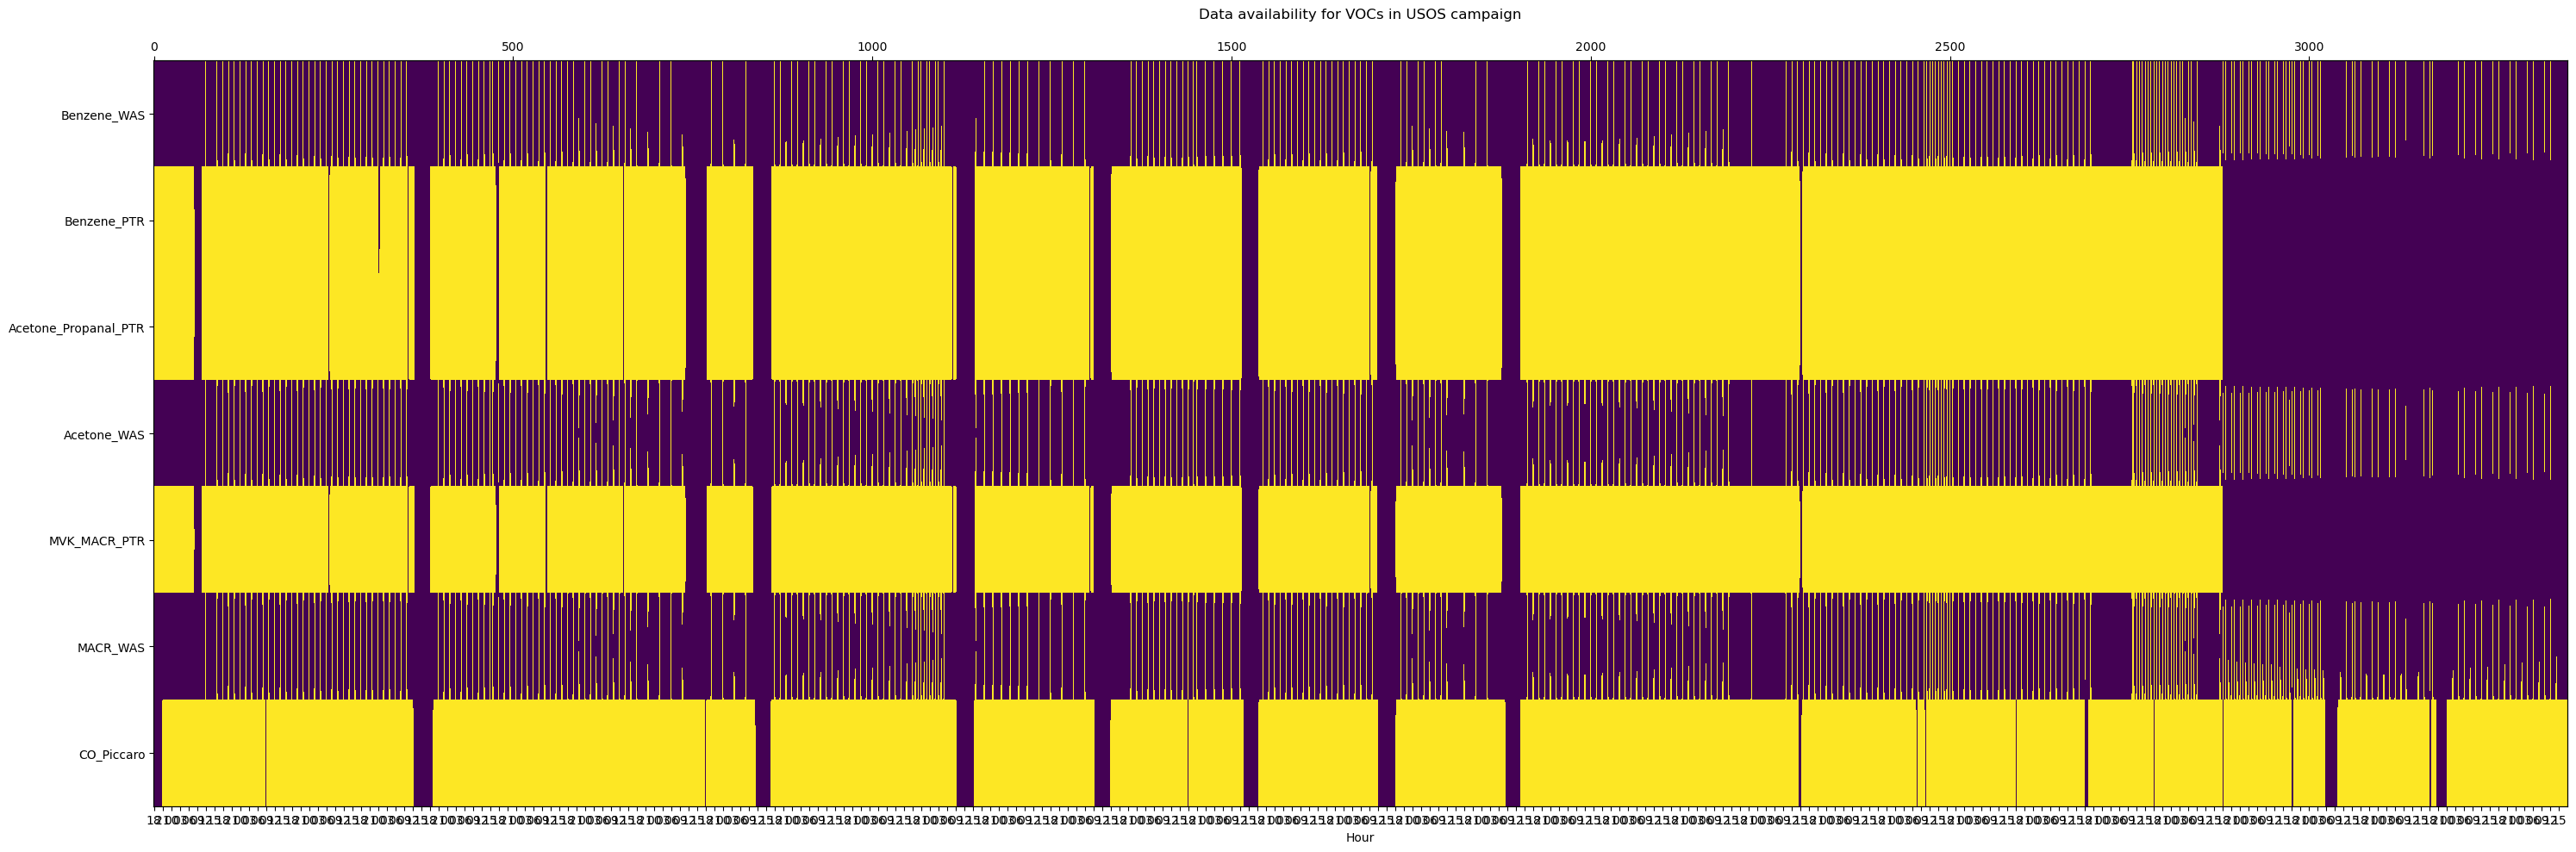

In [10]:
#alter viridis colormap to only have 2 color options
viridis = plt.cm.viridis
colors = [viridis(0.0), viridis(1.0)]
two_color_viridis = ListedColormap(colors)

# Create the heatmap using imshow
fig, ax = plt.subplots(figsize=(30, 10))
ax.imshow(df_usos_vocs_transposed[0:7], aspect='auto', cmap=two_color_viridis)
# Set x-ticks and y-ticks
ax.set_xticks(ticks=range(0,len(df_usos_vocs_transposed.columns),12), labels=df_usos_vocs_transposed.columns.strftime('%H')[0::12])
ax.set_yticks(ticks=np.arange(len(df_usos_vocs_transposed.index[0:7])), labels=df_usos_vocs_transposed.index[0:7])
ax.set_xlabel('Hour')

# for pos in range(12,len(df_usos_vocs_transposed.columns),48):
#     plt.axvline(pos, color = 'black')
#    plt.axvline(df_allvars_transposed.columns.strftime('%H%M')[12::48], color = 'black')           

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
midnight_labels = []
# for date in range(12,len(df_usos_vocs_transposed.columns),48):
#     date_labels = df_usos_vocs_transposed.columns.strftime('%m-%d')[date]
#     midnight_labels.append(date_labels)

# ax_top.set_xticklabels(midnight_labels)
# ax_top.set_xticks(ticks=range(12,len(df_usos_vocs_transposed.columns),48))

# Set labels and title

plt.ylabel('Measurement')
plt.title('Data availability for VOCs in USOS campaign\n')

# Show plot
plt.tight_layout()
plt.show()

In [ ]:
dirpath = '/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/'

udaq_f = dirpath + '/Hawthorne_data/data/script_output/hawthorne_udaq_all_vocs_15min_timezone_carbon_number_updated.csv'
udaq = pd.read_csv(udaq_f, index_col='time_local', parse_dates=True)
#For some reason, pandas is reading the time_local as UTC so we change it back to reading as the UTC-6 time zone
udaq.index = udaq.index.tz_localize(None)
udaq.index = udaq.index.tz_localize('America/Denver')
#Datetime index has 15 min intervals, and from from 07/14/2024 18:00:00 to 8/18/2024 17:45:00 MDT
#Set index to only include 2024-07-15 00:00:00 to 2024-08-18 17:45:00 MDT
udaq = udaq.loc['2024-07-15 00:00:00':'2024-08-18 17:45:00']
# Set any inf, neg. inf, and negative values to NaN
for col in udaq.columns[1:len(udaq.columns)+1]:
    udaq[col] = udaq[col].replace([np.inf, -np.inf], np.nan).mask(udaq[col] < 0, np.nan)
#print(udaq['Benzene'])

df_alldays_crop = df_alldays.loc['2024-07-15 00:00:00':'2024-08-18 17:45:00']
df_alldays_crop.index = df_alldays_crop.index.tz_localize('America/Denver')

udaq_cols = ['Benzene', 'Toluene', 'Ethane']
df_alldays_crop.loc[:,udaq_cols] = udaq[udaq_cols]
#print(df_alldays_crop['Benzene'])

VOC_list = ['Acetone_Propanal_PTR', 'Acetone_WAS', 'MVK_MACR_PTR', 'MACR_WAS', 'CO_Piccaro', 'Benzene_WAS', 'Benzene_PTR', 'Benzene', 'Toluene_WAS', 'Toluene_PTR', 'Toluene', 'Ethane_WAS', 'Ethane', 'NO_LIF', 'O3_ppbv', 'ISOPN_CIMS', 'BrCl_CIMS','Br2_CIMS', 'Cl2_CIMS', 'ClNO2_CIMS', 'NOy_LIF', 'HNO3_CIMS', 'N2O5_CIMS', 'CH4_CRDS']

df_usos_vocs=pd.DataFrame(index=df_alldays_crop.index)
for instr in VOC_list:
    # Everything that was a NaN or negative is assigned a 0, positive values are assigned a 1
    df_usos_vocs[instr] = np.where((df_alldays_crop[instr] > 0) & (~df_alldays_crop[instr].isna()), 1, 0)
df_usos_vocs_transposed=df_usos_vocs.T

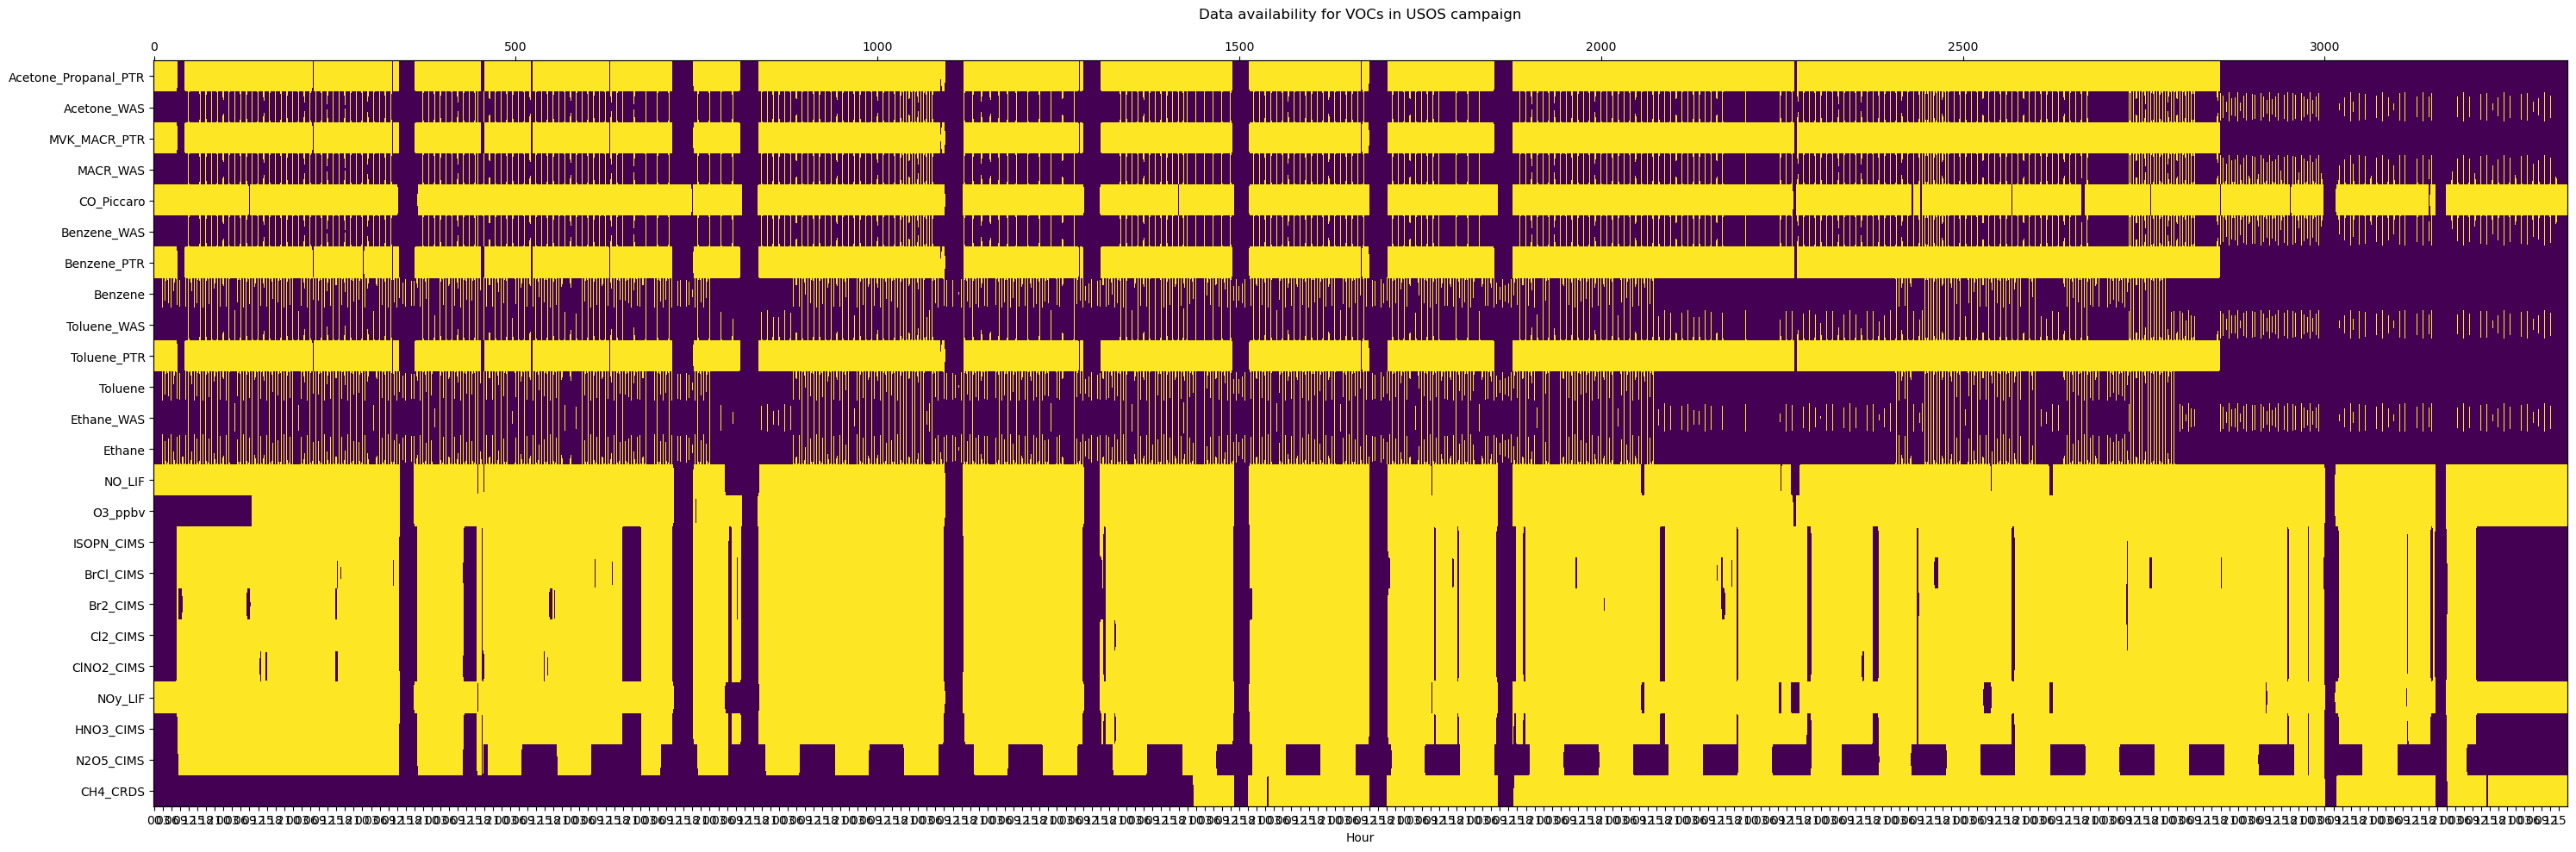

In [17]:
#alter viridis colormap to only have 2 color options
viridis = plt.cm.viridis
colors = [viridis(0.0), viridis(1.0)]
two_color_viridis = ListedColormap(colors)

# Create the heatmap using imshow
fig, ax = plt.subplots(figsize=(30, 10))
ax.imshow(df_usos_vocs_transposed[0:len(VOC_list)], aspect='auto', cmap=two_color_viridis)
# Set x-ticks and y-ticks
ax.set_xticks(ticks=range(0,len(df_usos_vocs_transposed.columns),12), labels=df_usos_vocs_transposed.columns.strftime('%H')[0::12])
ax.set_yticks(ticks=np.arange(len(df_usos_vocs_transposed.index[0:len(VOC_list)])), labels=df_usos_vocs_transposed.index[0:len(VOC_list)])
ax.set_xlabel('Hour')

# for pos in range(12,len(df_usos_vocs_transposed.columns),48):
#     plt.axvline(pos, color = 'black')
#    plt.axvline(df_allvars_transposed.columns.strftime('%H%M')[12::48], color = 'black')           

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
midnight_labels = []
# for date in range(12,len(df_usos_vocs_transposed.columns),48):
#     date_labels = df_usos_vocs_transposed.columns.strftime('%m-%d')[date]
#     midnight_labels.append(date_labels)

# ax_top.set_xticklabels(midnight_labels)
# ax_top.set_xticks(ticks=range(12,len(df_usos_vocs_transposed.columns),48))

# Set labels and title

plt.ylabel('Measurement')
plt.title('Data availability for VOCs in USOS campaign\n')

# Show plot
plt.tight_layout()
plt.show()

In [28]:
dirpath = '/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/'

udaq_f = dirpath + '/Hawthorne_data/data/script_output/hawthorne_udaq_all_vocs_15min_timezone_carbon_number_updated.csv'
udaq = pd.read_csv(udaq_f, index_col='time_local', parse_dates=True)
#For some reason, pandas is reading the time_local as UTC so we change it back to reading as the UTC-6 time zone
udaq.index = udaq.index.tz_localize(None)
udaq.index = udaq.index.tz_localize('America/Denver')
#Datetime index has 15 min intervals, and from from 07/14/2024 18:00:00 to 8/18/2024 17:45:00 MDT
#Set index to only include 2024-07-15 00:00:00 to 2024-08-18 17:45:00 MDT
udaq = udaq.loc['2024-07-15 00:00:00':'2024-08-18 17:45:00']
# Set any inf, neg. inf, and negative values to NaN
for col in udaq.columns[1:len(udaq.columns)+1]:
    udaq[col] = udaq[col].replace([np.inf, -np.inf], np.nan).mask(udaq[col] < 0, np.nan)
#print(udaq['Benzene'])

df_alldays_crop = df_alldays.loc['2024-07-15 00:00:00':'2024-08-18 17:45:00']
df_alldays_crop.index = df_alldays_crop.index.tz_localize('America/Denver')

udaq_cols = ['Benzene', 'Toluene', 'Ethane']
df_alldays_crop.loc[:,udaq_cols] = udaq[udaq_cols]
#print(df_alldays_crop['Benzene'])

VOC_list = ['Acetone_Propanal_PTR', 'Acetaldehyde_PTR', 'MVK_MACR_PTR',    'Benzene_PTR',  'Toluene_PTR','Benzene', 'Toluene', 'Ethane','MACR_WAS','Acetone_WAS', 'Benzene_WAS','Toluene_WAS','Ethane_WAS', 'CO_Piccaro', 'CO2_Piccaro','NO_LIF', 'O3_ppbv','PAN_CIMS', 'ISOPN_CIMS', 'BrCl_CIMS','Br2_CIMS','BrO_CIMS', 'Cl2_CIMS', 'ClNO2_CIMS', 'NOy_LIF', 'HNO3_CIMS', 'HONO_CIMS','N2O5_CIMS', 'CH4_CRDS']

df_usos_vocs=pd.DataFrame(index=df_alldays_crop.index)
for instr in VOC_list:
    # Everything that was a NaN or negative is assigned a 0, positive values are assigned a 1
    df_usos_vocs[instr] = np.where((df_alldays_crop[instr] > 0) & (~df_alldays_crop[instr].isna()), 1, 0)
df_usos_vocs_transposed=df_usos_vocs.T

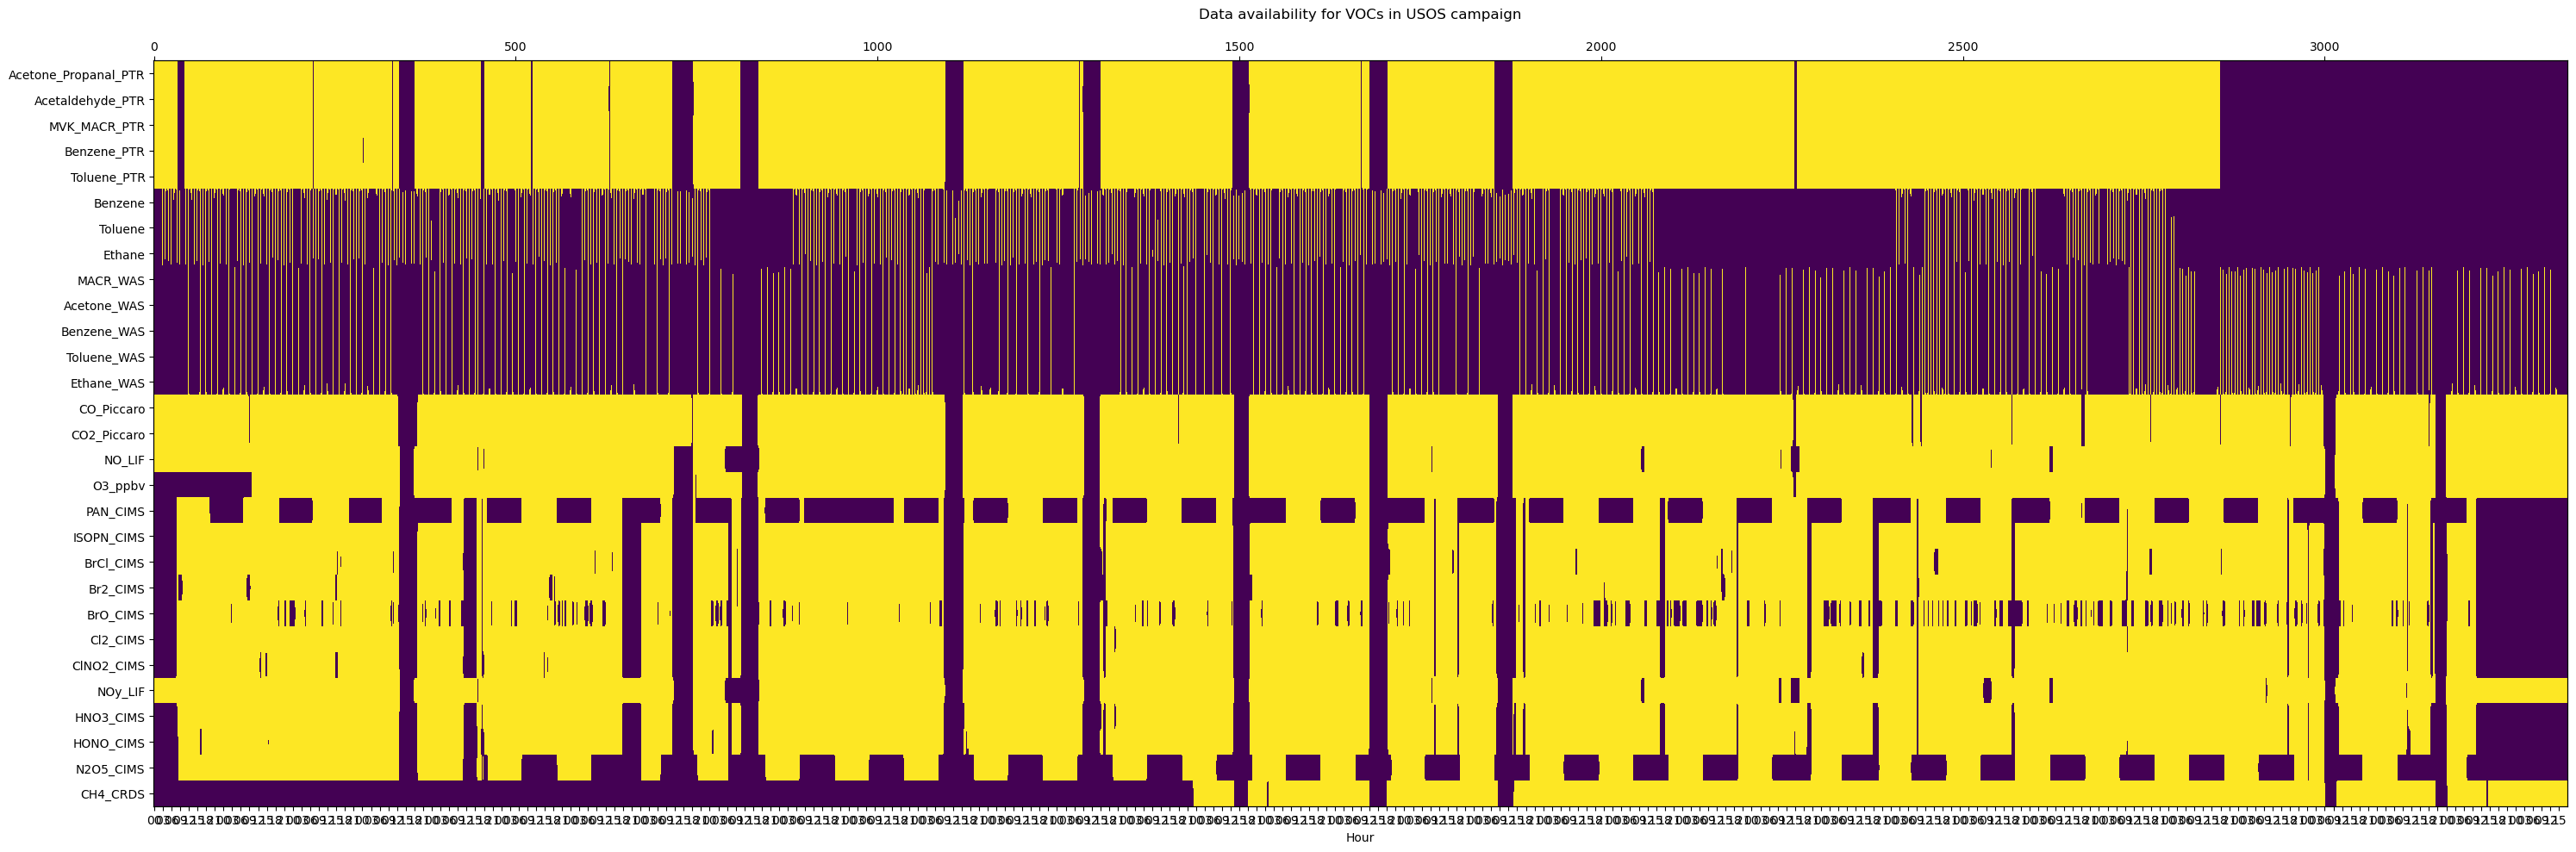

In [29]:
#alter viridis colormap to only have 2 color options
viridis = plt.cm.viridis
colors = [viridis(0.0), viridis(1.0)]
two_color_viridis = ListedColormap(colors)

# Create the heatmap using imshow
fig, ax = plt.subplots(figsize=(30, 10))
ax.imshow(df_usos_vocs_transposed[0:len(VOC_list)], aspect='auto', cmap=two_color_viridis)
# Set x-ticks and y-ticks
ax.set_xticks(ticks=range(0,len(df_usos_vocs_transposed.columns),12), labels=df_usos_vocs_transposed.columns.strftime('%H')[0::12])
ax.set_yticks(ticks=np.arange(len(df_usos_vocs_transposed.index[0:len(VOC_list)])), labels=df_usos_vocs_transposed.index[0:len(VOC_list)])
ax.set_xlabel('Hour')

# for pos in range(12,len(df_usos_vocs_transposed.columns),48):
#     plt.axvline(pos, color = 'black')
#    plt.axvline(df_allvars_transposed.columns.strftime('%H%M')[12::48], color = 'black')           

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
midnight_labels = []
# for date in range(12,len(df_usos_vocs_transposed.columns),48):
#     date_labels = df_usos_vocs_transposed.columns.strftime('%m-%d')[date]
#     midnight_labels.append(date_labels)

# ax_top.set_xticklabels(midnight_labels)
# ax_top.set_xticks(ticks=range(12,len(df_usos_vocs_transposed.columns),48))

# Set labels and title

plt.ylabel('Measurement')
plt.title('Data availability for VOCs in USOS campaign\n')

# Show plot
plt.tight_layout()
plt.show()